Computing the Constant Elasticity of Variance Option Pricing Formula, Schroder

In [1]:
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
def nc_chi(z, nu, kappa): # Munuswamy Sankaran. "Approximations to the Non-Central Chi-Square Distribution." Biometrika 50 (June 1963), 199
    h = 1 - (2/3) * (nu+kappa) * (nu+3*kappa) * ((nu+2*kappa) ** (-2))
    p = (nu+2*kappa) / ((nu+kappa) ** 2)
    m = (h-1) * (1-3*h)

    q = (1 - h*p*(1-h+0.5*(2-h)*m*p) - (z/(nu+kappa)) ** h) / (h * (2*p*(1+m*p)) ** 0.5)
    return norm.cdf(q)

In [3]:
# Verify approximation
z = 1 
k = 8
approx = nc_chi(z, 1, k)
print(approx)
exact = norm.cdf(k**0.5 - z**0.5) + norm.cdf(-k**0.5 - z**0.5)
print(exact)
print(approx/exact - 1)

0.969200341807518
0.9663217456201073
0.0029789210482513706


concepts to read up: 
- continuous proportional dividend rate

In [22]:
def cev(beta, r, a, t, sigma, S, E):
    g = (beta-2)/2
    delta = sigma / (S ** g)
    k = 2*(r - a) / (delta ** 2 * (2-beta) * (np.exp((r-a)*(2-beta)*t) - 1))
    x = k * S ** (2-beta) * np.exp((r-a)*(2-beta)*t)
    y = k * E ** (2- beta)
    call = S * np.exp(-a*t) * nc_chi(2*y, 2-1/g, 2*x) - E * np.exp(-r*t) * nc_chi(2*y, 2+1/g, 2*x)
    return call

def put_call_parity(call, r, a, t, S, E):
    return call + E * np.exp(-r*t) - S * np.exp(-a*t)

def continuous_proportional_dividend(r, f, T=1):
    return r - np.log(f)/T

def implied_dividend(C, P, S, E, t, r):    
    forward_value = C - P + E * np.exp(-r * t)
    return -(1/t) * np.log(forward_value / S)

In [23]:
r = 0.0436 # rf_rate
a = continuous_proportional_dividend(r,1+0.75/97.68,1) # continuous proportional dividend rate
t = 16/252   # maturity
sigma = 0.2617 # volatility
S = 97.68 # stock price
E = 104 # strike price
beta = 1 # takes values in [0,2)

print(cev(beta, r, a, t, sigma, S, E))

0.5881283701221562


In [21]:
r = 0.0436 # rf_rate
a = continuous_proportional_dividend(r,1+0.75/97.68,1) # continuous proportional dividend rate
t = 16/252   # maturity
sigma = 0.2617 # volatility
S = 97.68 # stock price
E = 104 # strike price
beta = 1 # takes values in [0,2)

print(cev(beta, r, a, t, sigma, S, E))

0.5881283701221562


In [19]:
dis = pd.read_csv('../../final_dataset/historical_option/NFLX.csv')
dis.expiration = pd.to_datetime(dis.expiration)
dis.date = pd.to_datetime(dis.date)
dis['moneyness'] = dis.strike / 97.68
dis['maturity'] = (dis.expiration-dis.date).dt.days / 252
dis['price'] = (dis.bid+dis.ask) / 2
seg = dis[(dis.expiration == '4/17/2025')]

In [20]:
for beta in range(20):
    prices = []
    beta /=10
    
    for i in range(int(len(dis)/2)):
        row = dis.iloc[2*i]
        C = row.price
        P = dis.iloc[2*i+1].price
        t = row.maturity
        E = row.strike
        
        a = implied_dividend(C, P, S, E, t, r)
        # print(a)
        
        call = cev(beta, r, a, t, sigma, S, E)
        prices.append(call)
        put = put_call_parity(call, r, a, t, S, E)
        prices.append(put)
    
    dis['cev_prices'] = prices
    dis['error'] = dis.cev_prices - dis.price
    print(beta)
    print(dis.error.describe())

0.0
count    114.000000
mean     -19.442203
std       11.591435
min      -40.159024
25%      -28.894099
50%      -18.669136
75%       -9.872051
max       -1.320000
Name: error, dtype: float64
0.1
count    114.000000
mean     -19.332388
std       11.462263
min      -39.693170
25%      -28.760706
50%      -18.632506
75%       -9.871040
max       -1.320000
Name: error, dtype: float64
0.2
count    114.000000
mean     -19.212224
std       11.322964
min      -39.195325
25%      -28.611373
50%      -18.587406
75%       -9.869666
max       -1.320000
Name: error, dtype: float64
0.3
count    114.000000
mean     -19.080371
std       11.172477
min      -38.662320
25%      -28.338543
50%      -18.531923
75%       -9.867796
max       -1.320000
Name: error, dtype: float64
0.4
count    114.000000
mean     -18.935278
std       11.009621
min      -38.090617
25%      -27.994883
50%      -18.463726
75%       -9.865247
max       -1.320000
Name: error, dtype: float64
0.5
count    114.000000
mean     -18.775

<Axes: >

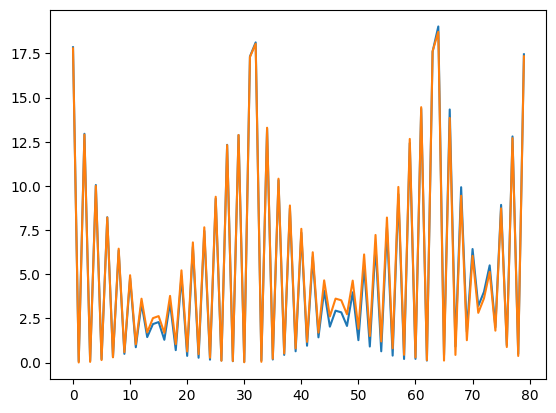

In [18]:
dis.price.plot()
dis.cev_prices.plot()